In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error 
import numpy as np

In [2]:
geo_0 = pd.read_csv(r"C:\Users\usuario1\Documents\geo\geo_data_0.csv")
geo_1 = pd.read_csv(r"C:\Users\usuario1\Documents\geo\geo_data_1.csv")
geo_2 = pd.read_csv(r"C:\Users\usuario1\Documents\geo\geo_data_2.csv")

In [3]:
geo_0.info()
geo_1.info()
geo_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null 

In [4]:
print('Region 0 :')
print(geo_0.describe)
print('Region 1 :')
print(geo_1.describe)
print('Region 2:')
print(geo_2.describe)

Region 0 :
<bound method NDFrame.describe of           id        f0        f1        f2     product
0      txEyH  0.705745 -0.497823  1.221170  105.280062
1      2acmU  1.334711 -0.340164  4.365080   73.037750
2      409Wp  1.022732  0.151990  1.419926   85.265647
3      iJLyR -0.032172  0.139033  2.978566  168.620776
4      Xdl7t  1.988431  0.155413  4.751769  154.036647
...      ...       ...       ...       ...         ...
99995  DLsed  0.971957  0.370953  6.075346  110.744026
99996  QKivN  1.392429 -0.382606  1.273912  122.346843
99997  3rnvd  1.029585  0.018787 -1.348308   64.375443
99998  7kl59  0.998163 -0.528582  1.583869   74.040764
99999  1CWhH  1.764754 -0.266417  5.722849  149.633246

[100000 rows x 5 columns]>
Region 1 :
<bound method NDFrame.describe of           id         f0         f1        f2     product
0      kBEdx -15.001348  -8.276000 -0.005876    3.179103
1      62mP7  14.272088  -3.475083  0.999183   26.953261
2      vyE1P   6.263187  -5.948386  5.001160  134.7

In [5]:
print('Valores_faltantes')
print(geo_0.isnull().sum())
print(geo_1.isnull().sum())
print(geo_2.isnull().sum())

Valores_faltantes
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64


En esta parte del codigo verifique que no hubieran datos faltantes

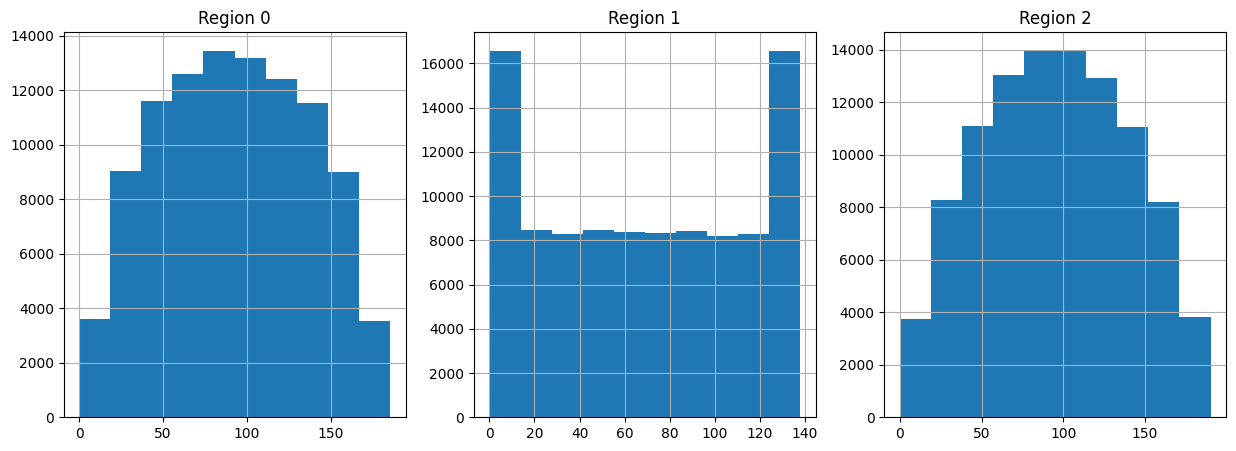

In [6]:
fig, axes = plt.subplots(1,3, figsize =(15,5))
geo_0['product'].hist(ax=axes[0])
axes[0].set_title('Region 0')
geo_1['product'].hist(ax=axes[1])
axes[1].set_title('Region 1')
geo_2['product'].hist(ax=axes[2])
axes[2].set_title('Region 2')
plt.show()

aqui compare la distribucion de las reservas de petroleo para cada region, que al verla podemos notar la distribucion de cada region, donde la region 0 tiene una distribucion de campana centrada alrededor de 100 unidades, mientras que la region 1 tiene  una distribucion extraña ya que muchos valores se acercan a 0 y muvhos valores son muy altos. y la region dos la cual tambien tiene una distribucion de campana solo que mas baja que la uno ya que esta alrededor de 70 a 80 unidades 

In [7]:
features = geo_0.drop(['product', 'id'], axis = 1)
target = geo_0['product']
features_train_0, features_valid_0, target_train_0, target_valid_0 = train_test_split(features , target, test_size = 0.25, random_state = 12345)

model = LinearRegression()
model.fit(features_train_0, target_train_0)
prediccion_0 = model.predict(features_valid_0)
rmse = mean_squared_error(target_valid_0, prediccion_0)**0.5
media_prediccion = prediccion_0.mean()
print('Region 0')
print('Volumen medio predicho:',media_prediccion)
print('RMSE :', rmse)

Region 0
Volumen medio predicho: 92.59256778438038
RMSE : 37.5794217150813


In [8]:
features_1 = geo_1.drop(['id', 'product'], axis = 1)
target_1 = geo_1['product']
features_train_1, features_valid_1, target_train_1, target_valid_1 = train_test_split (features_1, target_1, test_size = 0.25, random_state = 12345)
model_1 = LinearRegression()
model_1.fit(features_train_1, target_train_1)
predicciones_1 = model_1.predict(features_valid_1)
rmse = mean_squared_error(target_valid_1, predicciones_1)**0.5
media_prediccion_1 = predicciones_1.mean()
print('Region 1')
print('Volumen medio predicho :', media_prediccion_1)
print('RMSE :', rmse)


Region 1
Volumen medio predicho : 68.72854689544603
RMSE : 0.8930992867756165


In [9]:
features_2 = geo_2.drop(['id', 'product'], axis = 1)
target_2 = geo_2['product']
features_train_2, features_valid_2, target_train_2, target_valid_2 = train_test_split(features_2, target_2, test_size = 0.25, random_state = 12345)
model_2 = LinearRegression ()
model_2.fit(features_train_2, target_train_2)
prediccion_2 = model_2.predict(features_valid_2)
rmse = mean_squared_error(target_valid_2, prediccion_2)**0.5
media_prediccion_2= prediccion_2.mean()
print('Region 2')
print('Volumen medio predicho :',media_prediccion_2 )
print('RMSE:', rmse)

Region 2
Volumen medio predicho : 94.96504596800492
RMSE: 40.02970873393434


In [10]:
presupuesto_total = 100000000
pozos_a_desarollar= 200
inversion_por_pozo = presupuesto_total/ pozos_a_desarollar
ingreso_por_unidad = 4500
umbral_rentabilidad = inversion_por_pozo/ingreso_por_unidad
print(f'umbral minimo por pozo : {umbral_rentabilidad}')

umbral minimo por pozo : 111.11111111111111


aqui comprobamos cual seria nuestro umbral de netabilidad para cada pozo, siendo 111.1 unidades 

In [11]:
print(f'Umbral de rentabilidad :{umbral_rentabilidad}')
print(f'volumen medio region 0 :{media_prediccion}')
print(f'volumen medio region 1 :{media_prediccion_1}')
print(f'volumen medio region 2 :{media_prediccion_2}')

Umbral de rentabilidad :111.11111111111111
volumen medio region 0 :92.59256778438038
volumen medio region 1 :68.72854689544603
volumen medio region 2 :94.96504596800492


aqui checamos el volumen promedio de cada region, aunque ninguna de las tres regiones cumple con el umbral establecido, ya que el promedio de la region 0 es 92.5 unidades, el promedio de la region 1 es de 68.7 unidades, y el promedio de la region 2 es de 94.9 unidades, mientras el umbral de rentabilidad establecido es de 111.1 unidades

In [12]:
def calcular_ganancias(objetivo, predicciones):
    mejores_pozos = predicciones.argsort()[-200:]
    reservas_reales_seleccionadas= objetivo.iloc[mejores_pozos]
    ingresos_totales = reservas_reales_seleccionadas.sum()* ingreso_por_unidad
    ganancia = ingresos_totales - presupuesto_total
    return ganancia, reservas_reales_seleccionadas.sum()
    
    



aqui cree la funcion que nos dice cuales son los las ganancia de los 200 mejores pozos para cada region

In [13]:
ganancias_0, volumen_total_0 = calcular_ganancias(target_valid_0, prediccion_0)
ganancias_1, volumen_total_1 = calcular_ganancias(target_valid_1, predicciones_1)
ganancias_2, volumen_total_2 = calcular_ganancias(target_valid_2, prediccion_2)

print(f'Ganancias por region')
print(f'Ganancias region 0 : {ganancias_0}, Volumen total : {volumen_total_0} ')
print(f'Ganancias region 1 : {ganancias_1}, Volumen total : {volumen_total_1} ')
print(f'Ganancias region 2 : {ganancias_2}, Volumen total : {volumen_total_2} ')

Ganancias por region
Ganancias region 0 : 33208260.43139851, Volumen total : 29601.83565142189 
Ganancias region 1 : 24150866.966815114, Volumen total : 27589.081548181137 
Ganancias region 2 : 27103499.635998324, Volumen total : 28245.22214133296 


aqui aplicamos la funcion la cual nos dice que la region 0 es la que mas ganancias tiene con 33208260 seguido de la region 2 con 27103499, y al ultimo la region 1 con 24150866 , con estos resultados la propuesta clara es que la mejor region para invertir y hacer los 200 pozos es la region 0

In [14]:
def analisis_bootstrap(target, predictions):
    ganancias= []
    for i in range(1000):
        indices_aleatorios = np.random.choice(len(predictions),size = 500, replace =True)
        muestra_predicciones = predictions[indices_aleatorios]
        muestra_target = target.iloc[indices_aleatorios]
        mejores_pozos = muestra_predicciones.argsort()[-200:]
        volumen_real = muestra_target.iloc[mejores_pozos].sum()
        ingresos = volumen_real * 4500
        ganancias.append(ingresos - 100000000)
     
    return ganancias
        

aqui cree la funcion para sacar 1000 muestras diferentes de 500 pozos cada una, y sacando las ganancias de los mejores 200 pozos por region

In [15]:
ganancias_region_0 = analisis_bootstrap(target_valid_0, prediccion_0)

ganancias_region_1= analisis_bootstrap(target_valid_1, predicciones_1)

ganancias_region_2 = analisis_bootstrap(target_valid_2, prediccion_2)



In [16]:
def riesgo(ganancias):
    ganancias = np.array(ganancias)
    ganancia_promedio = np.mean(ganancias)
    percentil_2_5= np.percentile(ganancias, 2.5)
    percentil_97_5= np.percentile(ganancias, 97.5)
    perdidas = ganancias < 0
    riesgo_perdidas = np.mean(perdidas)*100
    return { 'ganancia promedio': ganancia_promedio, 
           'intervalo de confianza': (percentil_2_5, percentil_97_5),
           'riesgo_perdidas': riesgo_perdidas}

aqui cree la funcion para sacar la ganancia promedio, el intervalo de confianza y el riesgo de perdida para cada region.

In [17]:
analisis_final_0 = riesgo(ganancias_region_0)
analisis_final_1 = riesgo(ganancias_region_1)
analisis_final_2 = riesgo(ganancias_region_2)

print(f'Analisis final region 0 : {analisis_final_0}')
print(f'Analisis final region 1 : {analisis_final_1}')
print(f"Analisis final region 2 {analisis_final_2}")

Analisis final region 0 : {'ganancia promedio': np.float64(3900803.715988091), 'intervalo de confianza': (np.float64(-1228600.0517526302), np.float64(9336152.278865311)), 'riesgo_perdidas': np.float64(6.5)}
Analisis final region 1 : {'ganancia promedio': np.float64(4505137.368244902), 'intervalo de confianza': (np.float64(446323.9539623555), np.float64(8188352.736064645)), 'riesgo_perdidas': np.float64(1.3)}
Analisis final region 2 {'ganancia promedio': np.float64(3817695.2789759445), 'intervalo de confianza': (np.float64(-1773440.7914435095), np.float64(9127887.448570034)), 'riesgo_perdidas': np.float64(8.3)}


Con los resultados de las ganancias de cada region , utilice la funcion antes mencionada de riesgo, con la cual se logro sacar la ganancia promedio, el intervalo de confianza y el riesgo de perdidas de cada region , donde se pidio un analisis de riesgo menor a 2.5% siendo unicamente la region 1 la que cumple este requisito, ya que tiene un riesgo de perdidas de 1.1%, siendo la region que mas ganancias promedio tiene con un total de 4480754 , mintras que la region 2 tiene un riesgo de perdida de 7.2% y una ganancia promedio de 4030732 y la region 0 con un riesgo de perdidas de 6.5% y una ganancia promedio de 3948681

Como conclusion propongo la region 1 para el desarollo de pozos petroliferos, ya que es la region  qu cumple con el requisito de menos de 2.5% de riesgo de perdida y es la region con el menor riesgo de perdidad de las 3 con unicamente el 1.1% de riesgo de perdidas, y la mayor ganancia promedio, con un total de 4480754, aunque al inicio los datos se encaminaban a las otras regiones, mediante el analisis con bootstrap se pudo determinar que es la mejor region para invertir los 100 millones y hacer los 200 pozos petroliferos